# Notebook 2: Exploratory Data Analysis & Executive Visual Storytelling
### Industrial Training Kit — Batch 2026 | Powered by DecodeLabs
**Author:** Data Analytics Project Team  
**Dataset:** Audited E-Commerce Transactions (1,200 records x 14 raw features)

---

## Table of Contents
1. [Environment Setup & Custom Design System](#1-environment-setup--custom-design-system)
2. [Ingestion & Missingness Matrix Forensic Audit (Missingno)](#2-ingestion--missingness-matrix-forensic-audit)
3. [Feature Engineering](#3-feature-engineering)
4. [Univariate Analysis (Numeric & Categorical Distributions)](#4-univariate-analysis)
5. [Bivariate Analysis (Interactions & Collision-Free Annotations)](#5-bivariate-analysis)
6. [Multivariate Analysis (Dual Correlations, 4D Bubbles & Facet Grids)](#6-multivariate-analysis)
7. [Time Series Analysis (Seasonality, Moving Averages & Growth)](#7-time-series-analysis)
8. [Categorical Deep Dives (Funnels, Sankeys, Squarify Treemaps & Venn Overlaps)](#8-categorical-deep-dives)
9. [Advanced Interactive Visualizations (Plotly Engine)](#9-advanced-interactive-visualizations)
10. [Inferential Statistical Testing & Hypothesis Validation](#10-inferential-statistical-testing)
11. [Key Insights Summary & Strategic Action Plan](#11-key-insights-summary--strategic-action-plan)


### 1. Environment Setup & Custom Design System
We establish a unified, publication-grade design system:
- **Consistent Color Palette:** An enterprise 6-color hex palette reused across every plot instead of default matplotlib colors.
- **Typography:** Configured via `matplotlib.font_manager` prioritizing modern clean sans-serif typefaces (`Inter`, `Segoe UI`, `Roboto`).
- **Chart Polish Standards:** Elimination of redundant top/right chart spines (`sns.despine()`), standardized figure sizes (10x6, 14x6, 16x5), explicit currency data labels on bars (`bar_label`), and `plt.tight_layout()` on every figure.
- **Dual Visual Engine:** Matplotlib/Seaborn for statistical backbones + Plotly for interactive zoom, hover, and flow telemetry.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import missingno as msno
import squarify
from matplotlib_venn import venn3
from adjustText import adjust_text
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')

# 1.1 Enterprise 6-Color Consistent Palette
PALETTE = ['#3b82f6', '#10b981', '#f59e0b', '#fb7185', '#8b5cf6', '#06b6d4']
ACCENT_BLUE   = '#3b82f6'
ACCENT_GREEN  = '#10b981'
ACCENT_AMBER  = '#f59e0b'
ACCENT_ROSE   = '#fb7185'
ACCENT_PURPLE = '#8b5cf6'
ACCENT_CYAN   = '#06b6d4'
BG_SURFACE    = '#121215'
BORDER_COLOR  = '#27272a'
TEXT_PRIMARY  = '#f4f4f5'
TEXT_MUTED    = '#a1a1aa'

# 1.2 Publication-Grade Chart Polish Rules
plt.style.use('dark_background')
plt.rcParams['figure.dpi'] = 115
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Segoe UI', 'Roboto', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = BORDER_COLOR
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#222226'
plt.rcParams['grid.alpha'] = 0.5
sns.set_palette(PALETTE)

print("Unified custom design system and polish libraries configured successfully.")


Unified custom design system and polish libraries configured successfully.


### 2. Ingestion & Missingness Matrix Forensic Audit
Ingesting the cleaned dataset and executing a forensic visual missingness audit via `missingno` to confirm 100% matrix completeness before statistical modeling.


Dataset Ledger Audit: 1200 rows x 26 columns
Verified Nulls Across Matrix: 0


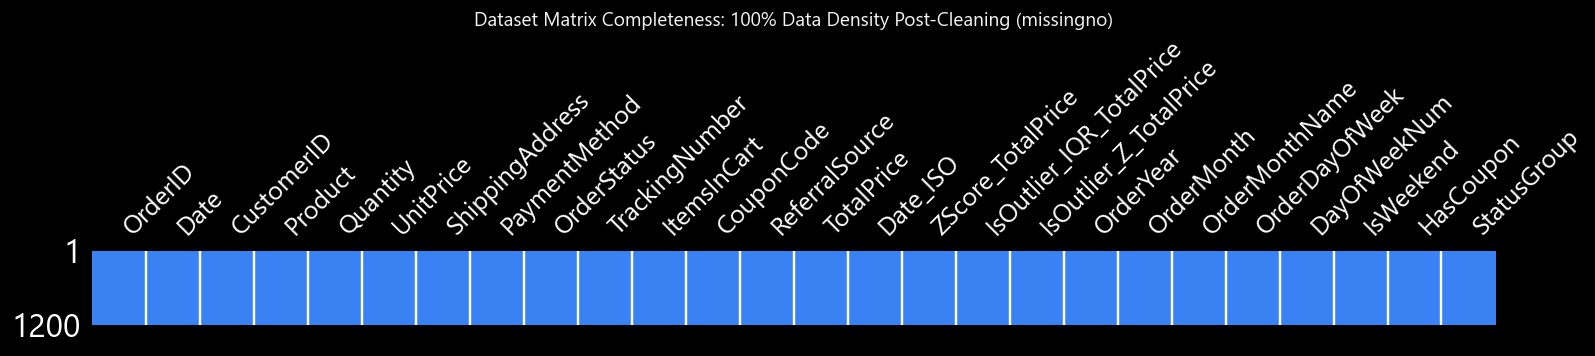

In [2]:
data_path = (
    '../data/processed/cleaned_ecommerce_data.csv'
    if os.path.exists('../data/processed/cleaned_ecommerce_data.csv')
    else 'data/processed/cleaned_ecommerce_data.csv'
)

df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date_ISO'])
print(f"Dataset Ledger Audit: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Verified Nulls Across Matrix: {df.isnull().sum().sum()}")

# Visual Missingness Audit via missingno
fig, ax = plt.subplots(figsize=(14, 3.2))
msno.matrix(df, sparkline=False, color=(0.23, 0.51, 0.96), ax=ax)
ax.set_title("Dataset Matrix Completeness: 100% Data Density Post-Cleaning (missingno)", color=TEXT_PRIMARY, fontsize=12)
plt.tight_layout()
plt.show()


### 3. Feature Engineering
Deriving strategic business dimensions:
1. **Temporal Dimensions:** `OrderYear`, `OrderMonth`, `OrderDay`, `DayOfWeek`, `DayName`, `IsWeekend`, `Quarter`.
2. **Financial & Ratio Metrics:** `PricePerCartItem` ($TotalPrice / ItemsInCart$), `UnitToTotalRatio`.
3. **Segmentation Bins & Buckets:** `OrderValueTier` (`Low <$500`, `Mid $500-$1,200`, `High >$1,200`), `CartSizeTier`, `QuantityTier`.
4. **Categorical Encodings:** Numerical category codes and normalized frequency weights for machine learning pipelines.


In [3]:
# 3.1 Date Decomposition
df['OrderYear'] = df['Date'].dt.year
df['OrderMonth'] = df['Date'].dt.to_period('M').astype(str)
df['OrderDay'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayName'] = df['Date'].dt.day_name()
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)

# 3.2 Financial Ratios
df['PricePerCartItem'] = (df['TotalPrice'] / df['ItemsInCart']).round(2)
df['UnitToTotalRatio'] = (df['UnitPrice'] / df['TotalPrice']).round(4)

# 3.3 Discretization & Bins
df['OrderValueTier'] = pd.cut(
    df['TotalPrice'],
    bins=[0, 500, 1200, 10000],
    labels=['Low (<$500)', 'Mid ($500-$1,200)', 'High (>$1,200)']
)
df['CartSizeTier'] = pd.cut(
    df['ItemsInCart'],
    bins=[0, 3, 7, 20],
    labels=['Small (1-3)', 'Medium (4-7)', 'Large (8+)']
)
df['QuantityTier'] = pd.cut(
    df['Quantity'],
    bins=[0, 2, 5, 20],
    labels=['Single/Dual (1-2)', 'Moderate (3-5)', 'Bulk (6+)']
)

# 3.4 Categorical Encoding
df['Status_Code'] = df['OrderStatus'].astype('category').cat.codes
df['Payment_Code'] = df['PaymentMethod'].astype('category').cat.codes
df['Product_Freq'] = df['Product'].map(df['Product'].value_counts(normalize=True)).round(4)

print("Engineered 12 diagnostic dimensions. Previewing engineered features:")
df[['Date_ISO', 'DayName', 'IsWeekend', 'PricePerCartItem', 'OrderValueTier', 'CartSizeTier', 'Product_Freq']].head(4)


Engineered 12 diagnostic dimensions. Previewing engineered features:


,Date_ISO,DayName,IsWeekend,PricePerCartItem,OrderValueTier,CartSizeTier,Product_Freq
0,2023-01-04,Wednesday,0,407.59,"High (>$1,200)",Medium (4-7),0.1358
1,2024-08-23,Friday,0,100.90,Low (<$500),Small (1-3),0.1300
2,2024-02-27,Tuesday,0,344.18,"High (>$1,200)",Large (8+),0.1492
3,2023-10-15,Sunday,1,54.64,Low (<$500),Medium (4-7),0.1483


### 4. Univariate Analysis
Examining the geometry of distribution for each individual variable in isolation.
- **Summary Statistics:** Central tendency, dispersion, and higher moments (skewness and kurtosis).
- **Numeric Distributions:** Histograms with Kernel Density Estimation (KDE) and box plots.
- **Categorical Distributions:** Polished value-count bar charts with `ax.bar_label` and proportion donut charts.


In [4]:
# 4.1 Comprehensive Descriptive Statistics Table
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart', 'PricePerCartItem']
summary_records = []

for c in num_cols:
    s = df[c]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    summary_records.append({
        'Feature': c,
        'Count': int(s.count()),
        'Mean': round(s.mean(), 2),
        'Std Dev': round(s.std(), 2),
        'Median': round(s.median(), 2),
        'Mode': round(s.mode().iloc[0], 2),
        'Min': round(s.min(), 2),
        'Q1 (25%)': round(q1, 2),
        'Q3 (75%)': round(q3, 2),
        'Max': round(s.max(), 2),
        'IQR': round(q3 - q1, 2),
        'Skewness': round(s.skew(), 3),
        'Kurtosis': round(s.kurt(), 3)
    })

summary_table = pd.DataFrame(summary_records)
summary_table


,Feature,Count,Mean,Std Dev,Median,Mode,Min,Q1 (25%),Q3 (75%),Max,IQR,Skewness,Kurtosis
0,Quantity,1200,2.95,1.41,3.00,1.00,1.00,2.00,4.00,5.00,2.00,0.028,-1.295
1,UnitPrice,1200,356.41,197.18,364.21,127.18,11.39,186.06,521.57,699.93,335.51,-0.027,-1.191
2,TotalPrice,1200,1053.97,819.86,823.62,211.14,11.39,410.52,1578.48,3456.40,1167.96,0.891,-0.040
3,ItemsInCart,1200,5.48,2.28,5.00,5.00,1.00,4.00,7.00,10.00,3.00,0.001,-0.709
4,PricePerCartItem,1200,207.72,154.23,172.68,29.38,1.90,83.05,301.20,697.93,218.15,0.921,0.326


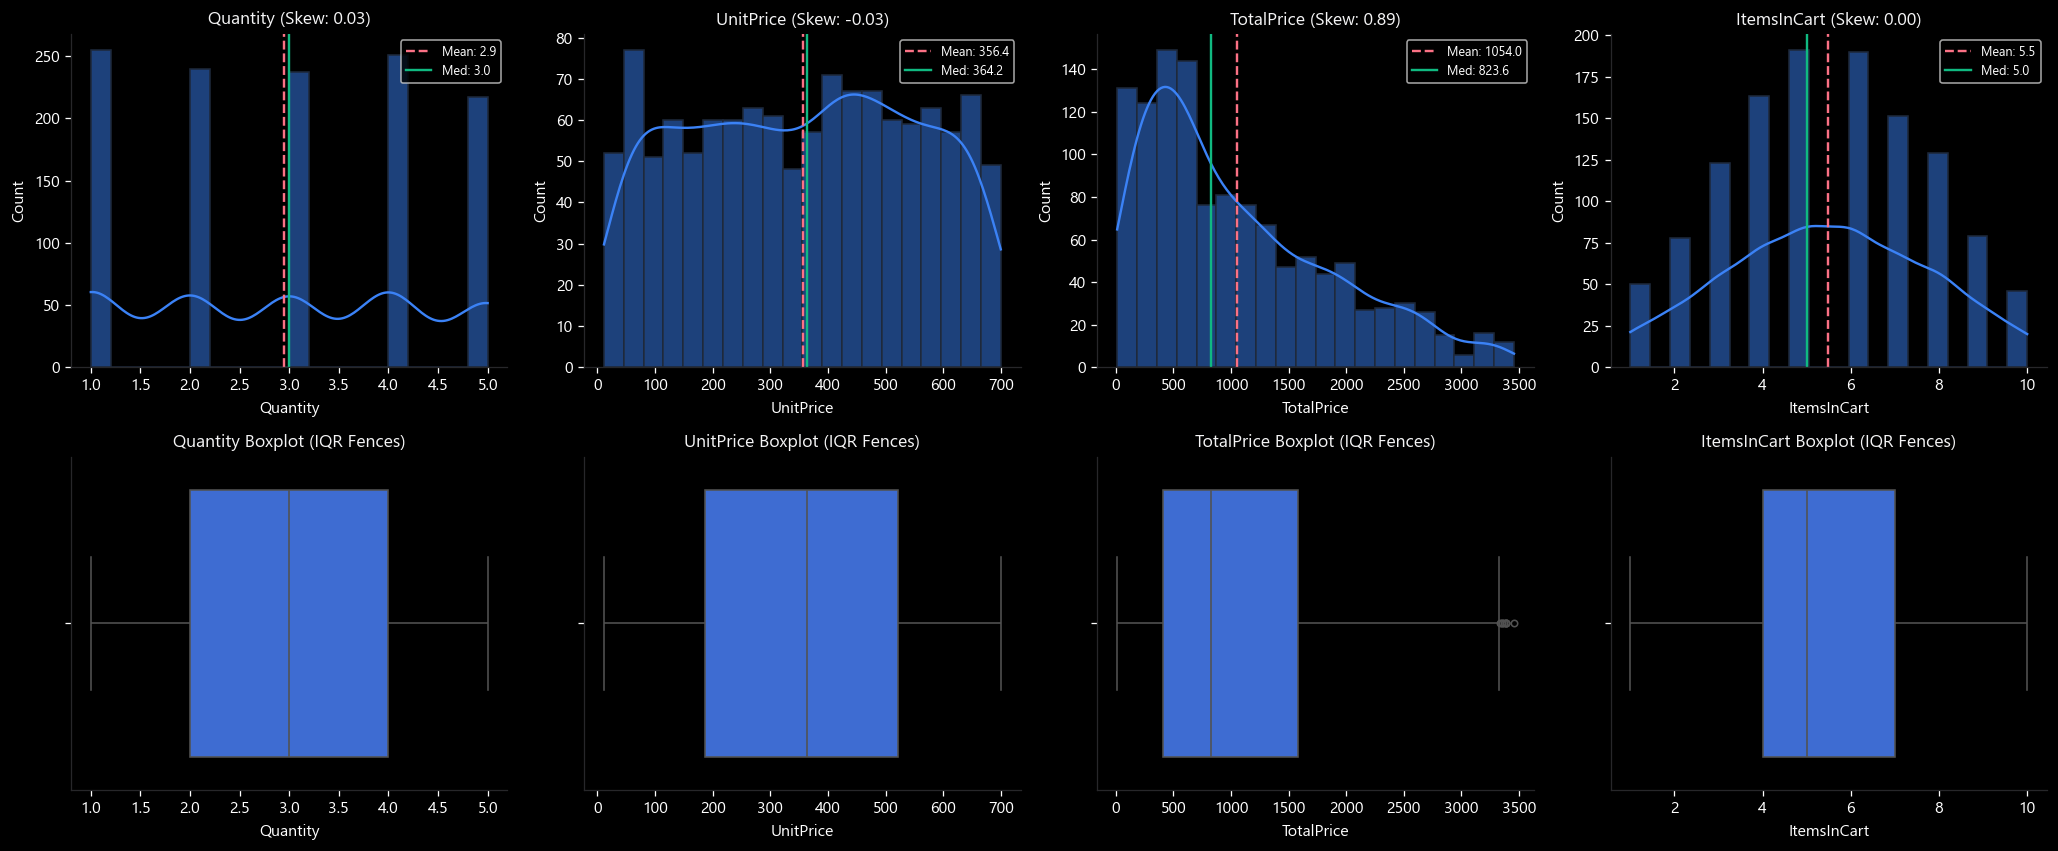

In [5]:
# 4.2 Numeric Visualizations: Histograms with KDE & Box Plots
fig, axes = plt.subplots(2, 4, figsize=(18, 7.5))
eval_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']

for i, col in enumerate(eval_cols):
    # Top row: KDE Distribution
    sns.histplot(df[col], kde=True, ax=axes[0, i], color=ACCENT_BLUE, bins=20, edgecolor='#1e293b')
    axes[0, i].set_title(f"{col} (Skew: {df[col].skew():.2f})", color=TEXT_PRIMARY, fontsize=11)
    axes[0, i].axvline(df[col].mean(), color=ACCENT_ROSE, linestyle='--', label=f"Mean: {df[col].mean():.1f}")
    axes[0, i].axvline(df[col].median(), color=ACCENT_GREEN, linestyle='-', label=f"Med: {df[col].median():.1f}")
    axes[0, i].legend(fontsize=8)
    sns.despine(ax=axes[0, i], top=True, right=True)
    
    # Bottom row: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='#2563eb', fliersize=4)
    axes[1, i].set_title(f"{col} Boxplot (IQR Fences)", color=TEXT_PRIMARY, fontsize=11)
    sns.despine(ax=axes[1, i], top=True, right=True)

plt.tight_layout()
plt.show()


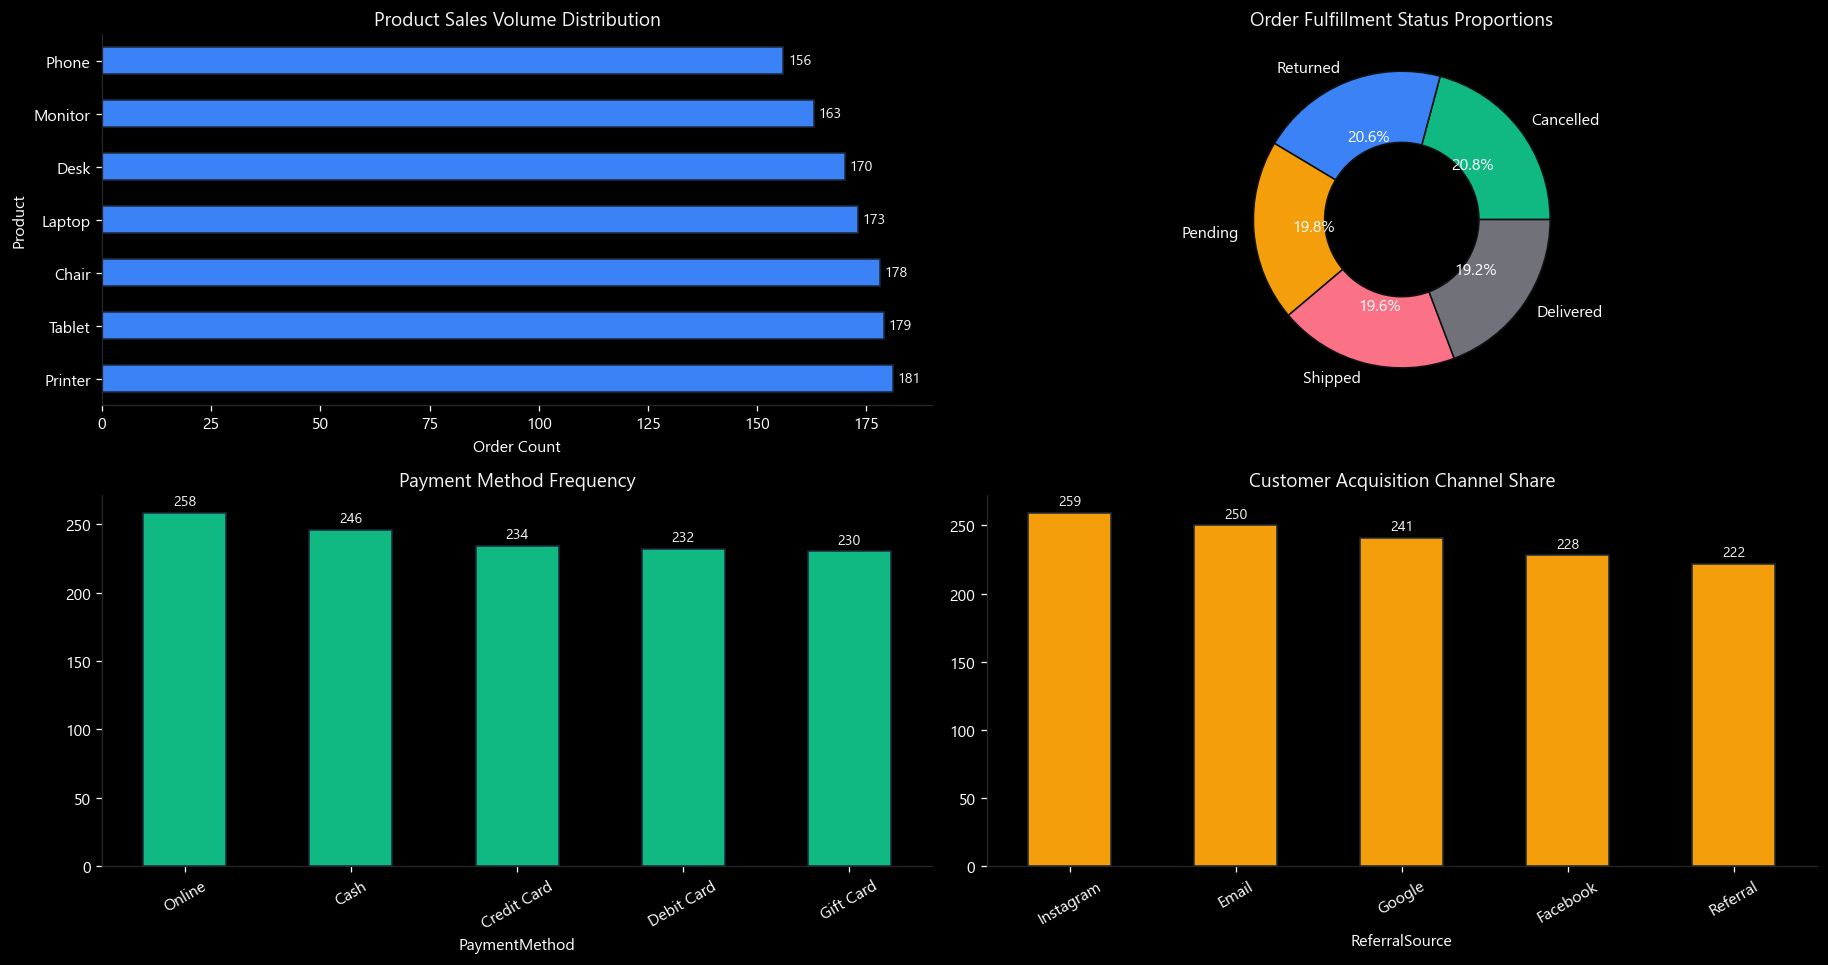

In [6]:
# 4.3 Categorical Distributions: Frequency Bars with Data Labels & Donut Shares
fig, axes = plt.subplots(2, 2, figsize=(16, 8.5))

# Product Volume with bar labels
p_counts = df['Product'].value_counts()
ax_p = p_counts.plot(kind='barh', ax=axes[0, 0], color=ACCENT_BLUE, edgecolor='#1e293b')
axes[0, 0].set_title("Product Sales Volume Distribution", color=TEXT_PRIMARY)
axes[0, 0].set_xlabel("Order Count")
axes[0, 0].bar_label(ax_p.containers[0], padding=3, color=TEXT_PRIMARY, fontsize=9)
sns.despine(ax=axes[0, 0], top=True, right=True)

# Order Status Donut Chart
status_colors = [ACCENT_GREEN, ACCENT_BLUE, ACCENT_AMBER, ACCENT_ROSE, '#71717a']
df['OrderStatus'].value_counts().plot(
    kind='pie', ax=axes[0, 1], autopct='%1.1f%%',
    colors=status_colors, wedgeprops=dict(width=0.48, edgecolor='#121215')
)
axes[0, 1].set_title("Order Fulfillment Status Proportions", color=TEXT_PRIMARY)
axes[0, 1].set_ylabel("")

# Payment Method Distribution with labels
pm_counts = df['PaymentMethod'].value_counts()
ax_pm = pm_counts.plot(kind='bar', ax=axes[1, 0], color=ACCENT_GREEN, edgecolor='#1e293b')
axes[1, 0].set_title("Payment Method Frequency", color=TEXT_PRIMARY)
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].bar_label(ax_pm.containers[0], padding=3, color=TEXT_PRIMARY, fontsize=9)
sns.despine(ax=axes[1, 0], top=True, right=True)

# Referral Source Distribution with labels
ref_counts = df['ReferralSource'].value_counts()
ax_ref = ref_counts.plot(kind='bar', ax=axes[1, 1], color=ACCENT_AMBER, edgecolor='#1e293b')
axes[1, 1].set_title("Customer Acquisition Channel Share", color=TEXT_PRIMARY)
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].bar_label(ax_ref.containers[0], padding=3, color=TEXT_PRIMARY, fontsize=9)
sns.despine(ax=axes[1, 1], top=True, right=True)

plt.tight_layout()
plt.show()


### 5. Bivariate Analysis
Interrogating relationships between paired variables:
- **Numeric vs. Numeric:** Scatter plots with OLS regression lines and **collision-free annotation placement via `adjustText`**.
- **Numeric vs. Categorical:** Violin plots and boxplots comparing revenue across categories.
- **Categorical vs. Categorical:** 100% stacked bar charts and cross-tabulation heatmaps.


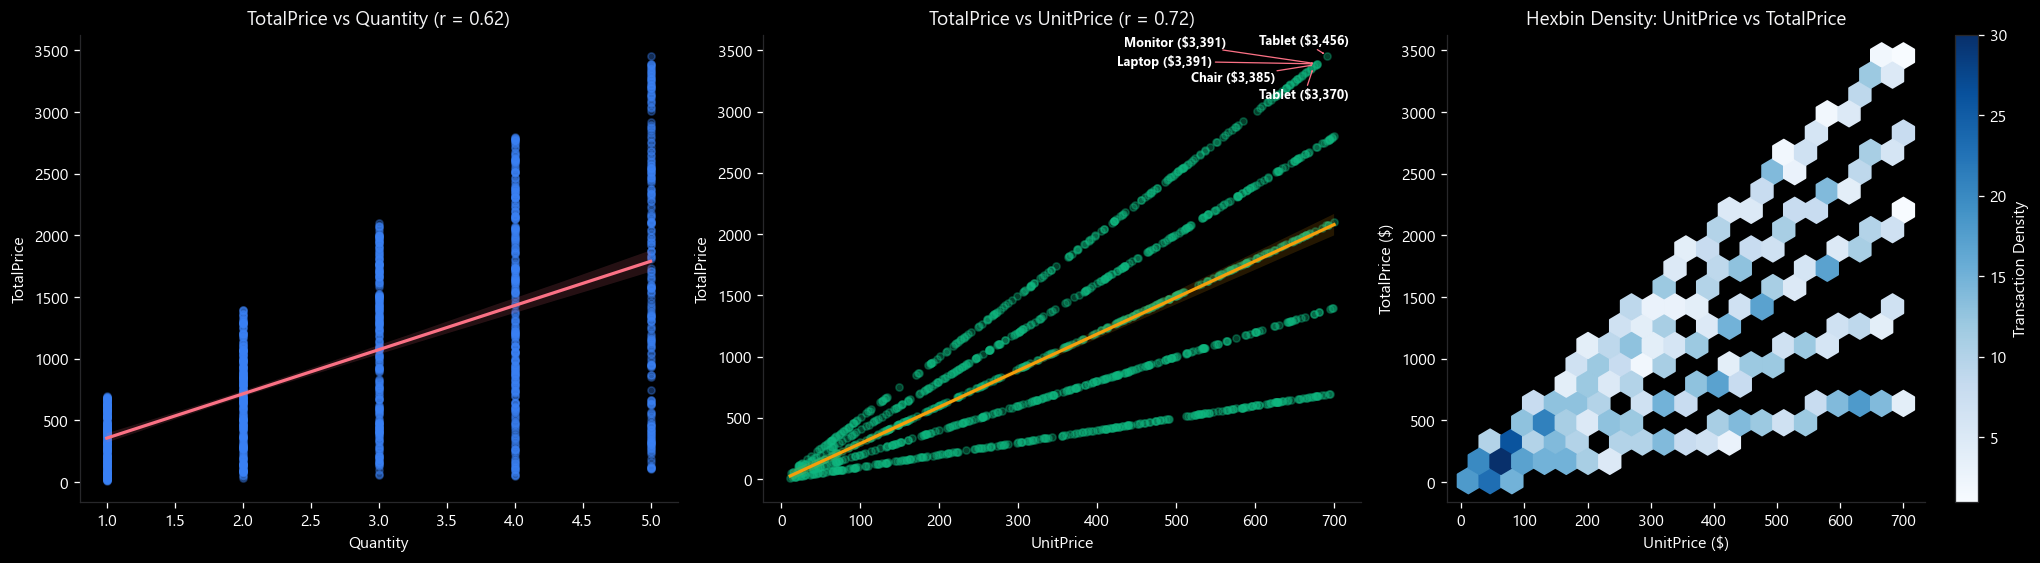

In [7]:
# 5.1 Numeric vs. Numeric: Scatter with OLS & adjustText Non-Overlapping Labels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TotalPrice vs Quantity
sns.regplot(
    data=df, x='Quantity', y='TotalPrice', ax=axes[0], color=ACCENT_BLUE,
    scatter_kws={'alpha': 0.35, 's': 20}, line_kws={'color': ACCENT_ROSE, 'linewidth': 2}
)
axes[0].set_title(f"TotalPrice vs Quantity (r = {df['TotalPrice'].corr(df['Quantity']):.2f})", color=TEXT_PRIMARY)
sns.despine(ax=axes[0], top=True, right=True)

# TotalPrice vs UnitPrice with adjustText for Top-5 Outlier Orders
sns.regplot(
    data=df, x='UnitPrice', y='TotalPrice', ax=axes[1], color=ACCENT_GREEN,
    scatter_kws={'alpha': 0.35, 's': 20}, line_kws={'color': ACCENT_AMBER, 'linewidth': 2}
)
axes[1].set_title(f"TotalPrice vs UnitPrice (r = {df['TotalPrice'].corr(df['UnitPrice']):.2f})", color=TEXT_PRIMARY)

# Collision-Free Top Order Annotations via adjustText
top_orders = df.nlargest(5, 'TotalPrice')
texts = []
for _, row in top_orders.iterrows():
    texts.append(axes[1].text(row['UnitPrice'], row['TotalPrice'], f"{row['Product']} (${row['TotalPrice']:,.0f})", fontsize=8, color='#fff', weight='bold'))
adjust_text(texts, ax=axes[1], arrowprops=dict(arrowstyle='->', color=ACCENT_ROSE, lw=0.8))
sns.despine(ax=axes[1], top=True, right=True)

# Hexbin Density Plot
hb = axes[2].hexbin(df['UnitPrice'], df['TotalPrice'], gridsize=20, cmap='Blues', mincnt=1)
axes[2].set_title("Hexbin Density: UnitPrice vs TotalPrice", color=TEXT_PRIMARY)
axes[2].set_xlabel("UnitPrice ($)")
axes[2].set_ylabel("TotalPrice ($)")
plt.colorbar(hb, ax=axes[2], label='Transaction Density')
sns.despine(ax=axes[2], top=True, right=True)

plt.tight_layout()
plt.show()


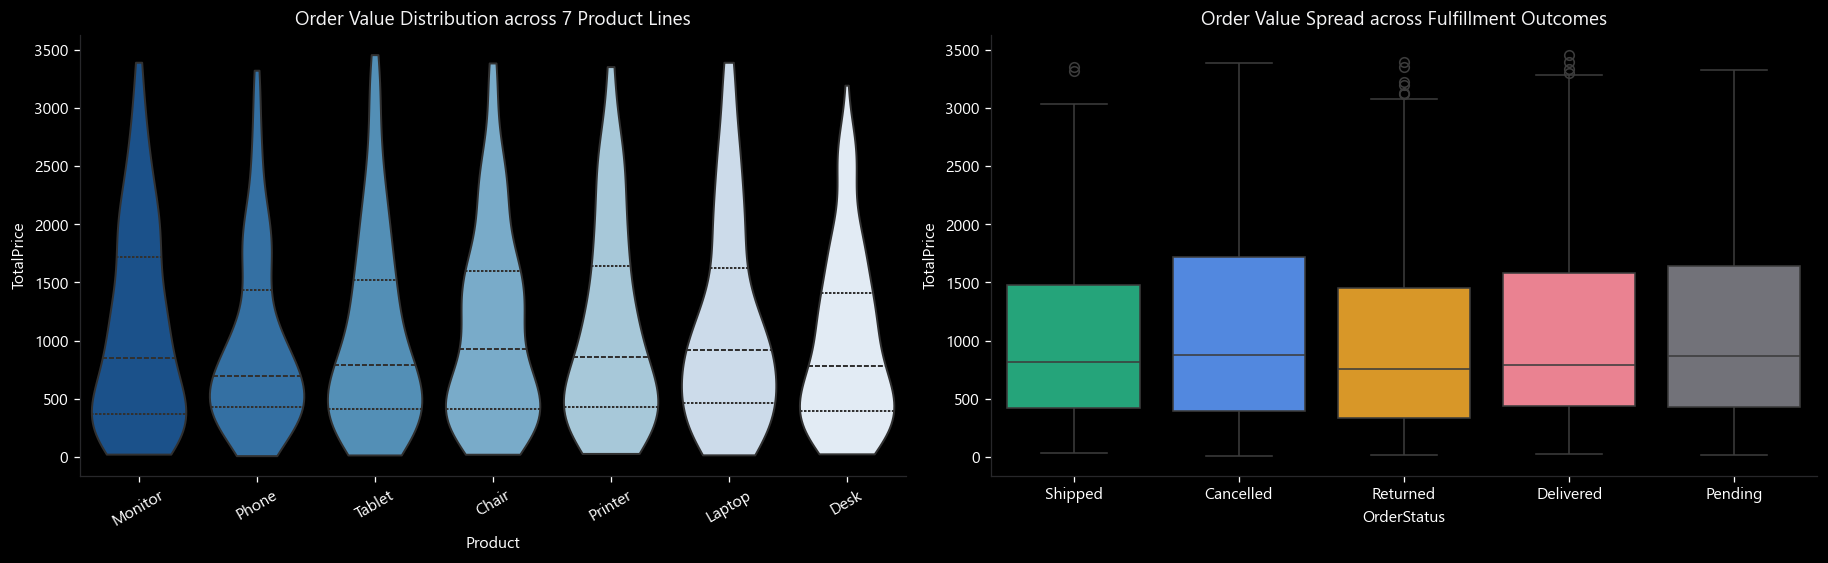

In [8]:
# 5.2 Numeric vs. Categorical: Violin & Box Plots across Categories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Violin Plot of TotalPrice across Products
sns.violinplot(
    data=df, x='Product', y='TotalPrice', ax=axes[0],
    palette='Blues_r', inner='quartile', cut=0
)
axes[0].set_title("Order Value Distribution across 7 Product Lines", color=TEXT_PRIMARY)
axes[0].tick_params(axis='x', rotation=30)
sns.despine(ax=axes[0], top=True, right=True)

# Boxplot of TotalPrice across Order Statuses
sns.boxplot(
    data=df, x='OrderStatus', y='TotalPrice', ax=axes[1],
    palette=[ACCENT_GREEN, ACCENT_BLUE, ACCENT_AMBER, ACCENT_ROSE, '#71717a']
)
axes[1].set_title("Order Value Spread across Fulfillment Outcomes", color=TEXT_PRIMARY)
sns.despine(ax=axes[1], top=True, right=True)

plt.tight_layout()
plt.show()


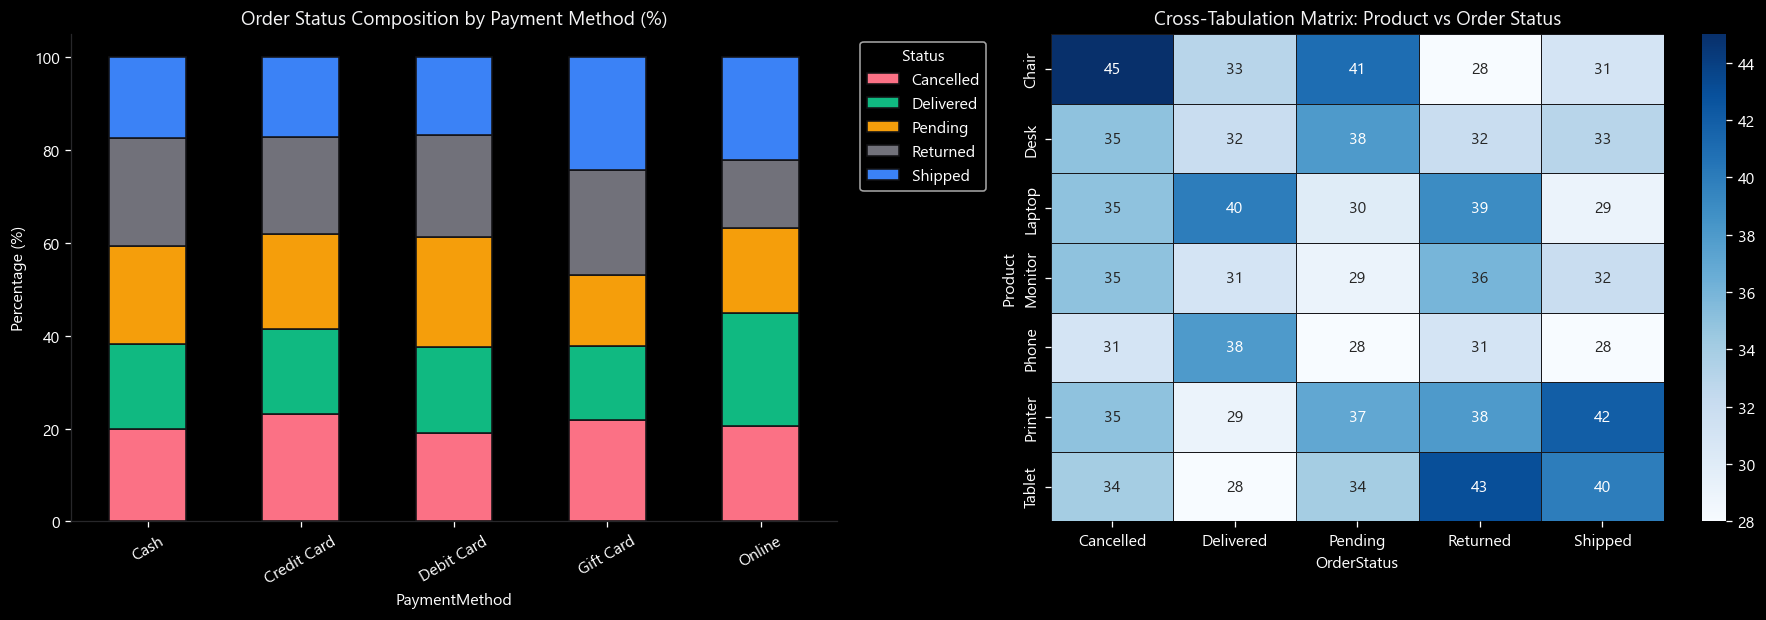

In [9]:
# 5.3 Categorical vs. Categorical: Stacked Proportions & Crosstab Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Stacked Bar: Payment Method vs Order Status
ct_pay = pd.crosstab(df['PaymentMethod'], df['OrderStatus'], normalize='index') * 100
ct_pay.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[ACCENT_ROSE, ACCENT_GREEN, ACCENT_AMBER, '#71717a', ACCENT_BLUE], edgecolor='#121215'
)
axes[0].set_title("Order Status Composition by Payment Method (%)", color=TEXT_PRIMARY)
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(ax=axes[0], top=True, right=True)

# Heatmap: Product vs Order Status
ct_prod = pd.crosstab(df['Product'], df['OrderStatus'])
sns.heatmap(
    ct_prod, annot=True, fmt='d', cmap='Blues', ax=axes[1],
    cbar=True, linewidths=0.5, linecolor='#18181c'
)
axes[1].set_title("Cross-Tabulation Matrix: Product vs Order Status", color=TEXT_PRIMARY)

plt.tight_layout()
plt.show()


### 6. Multivariate Analysis
Investigating higher-dimensional dynamics across continuous and discrete attributes:
- **Correlation Heatmaps:** Comparing Pearson linear correlation vs. Spearman rank monotonic correlation.
- **4D Bubble Analysis:** Encoding Quantity (X), TotalPrice (Y), ItemsInCart (Size), and Product (Color).
- **Facet Grids:** Conditional distributions split by categorical factors.


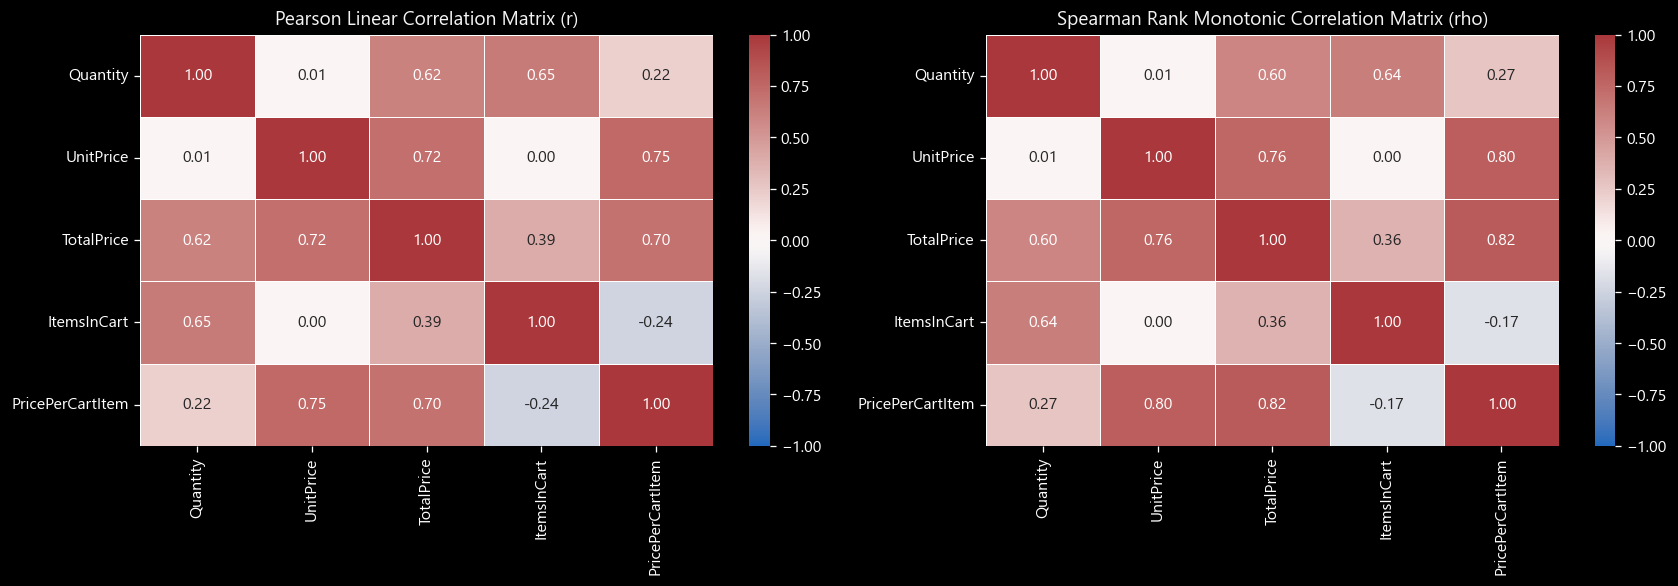

In [10]:
# 6.1 Pearson vs Spearman Correlation Matrix Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
corr_vars = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart', 'PricePerCartItem']

pearson = df[corr_vars].corr(method='pearson')
spearman = df[corr_vars].corr(method='spearman')

sns.heatmap(pearson, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title("Pearson Linear Correlation Matrix (r)", color=TEXT_PRIMARY)

sns.heatmap(spearman, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axes[1], linewidths=0.5)
axes[1].set_title("Spearman Rank Monotonic Correlation Matrix (rho)", color=TEXT_PRIMARY)

plt.tight_layout()
plt.show()


In [11]:
# 6.2 4-Dimensional Bubble Chart (Plotly)
fig = px.scatter(
    df, x='Quantity', y='TotalPrice',
    size='ItemsInCart', color='Product',
    hover_data=['OrderID', 'CustomerID', 'UnitPrice', 'OrderStatus', 'PaymentMethod'],
    title="4D Multivariate Bubble Analysis: Quantity vs Revenue by Product & Cart Size",
    template='plotly_dark', height=550
)
fig.update_layout(paper_bgcolor='#121215', plot_bgcolor='#121215')
fig.show()


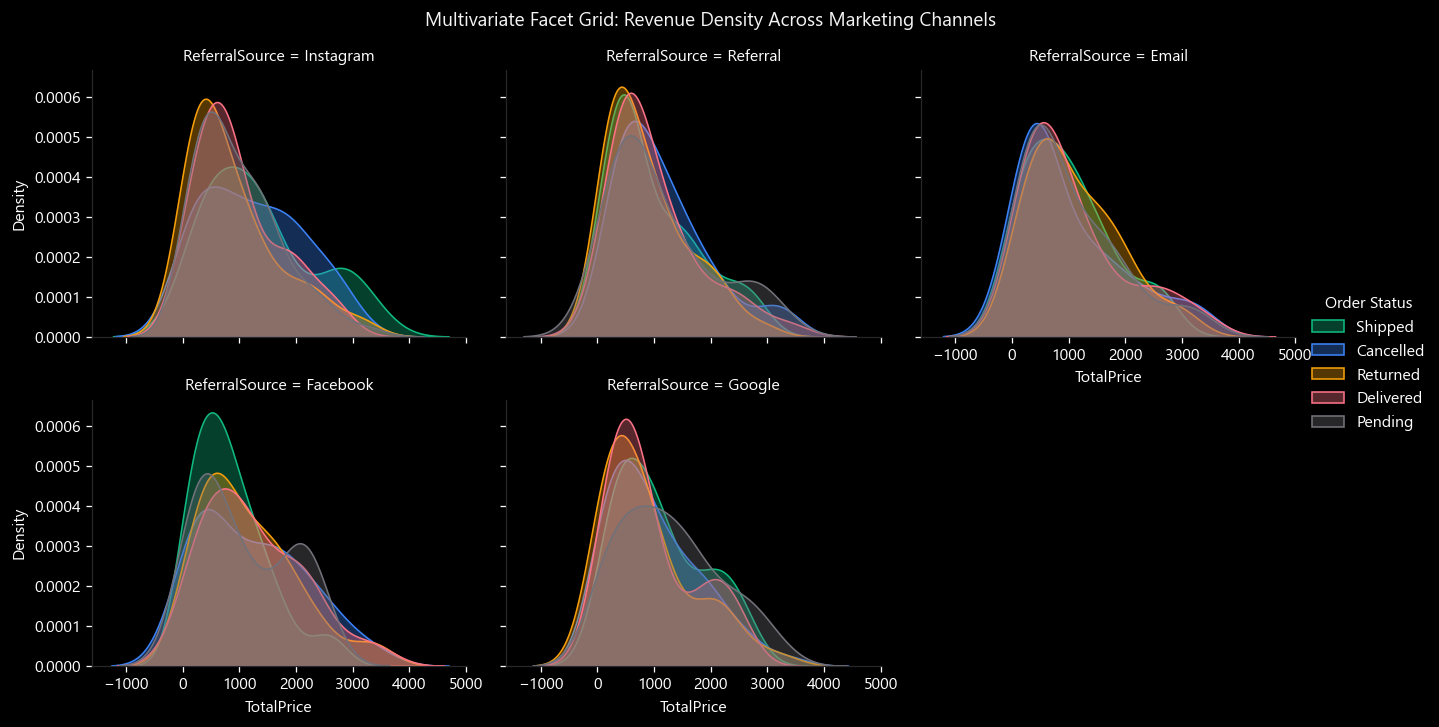

In [12]:
# 6.3 Multivariate Facet Grid
g = sns.FacetGrid(
    df, col='ReferralSource', hue='OrderStatus', col_wrap=3,
    height=3.2, aspect=1.2,
    palette=[ACCENT_GREEN, ACCENT_BLUE, ACCENT_AMBER, ACCENT_ROSE, '#71717a']
)
g.map(sns.kdeplot, 'TotalPrice', fill=True, alpha=0.35)
g.add_legend(title='Order Status')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Multivariate Facet Grid: Revenue Density Across Marketing Channels", color=TEXT_PRIMARY)
plt.show()


### 7. Time Series Analysis
Evaluating longitudinal trends across the 30-month timeline (January 2023 to June 2025):
- **Trajectory & Rolling Windows:** 3-month and 6-month moving averages smoothing volatility.
- **Seasonal Decomposition:** Extracting additive Trend, Seasonality, and Residual components.
- **Growth Rates:** Month-over-Month (MoM) % changes and Year-over-Year (YoY) performance.


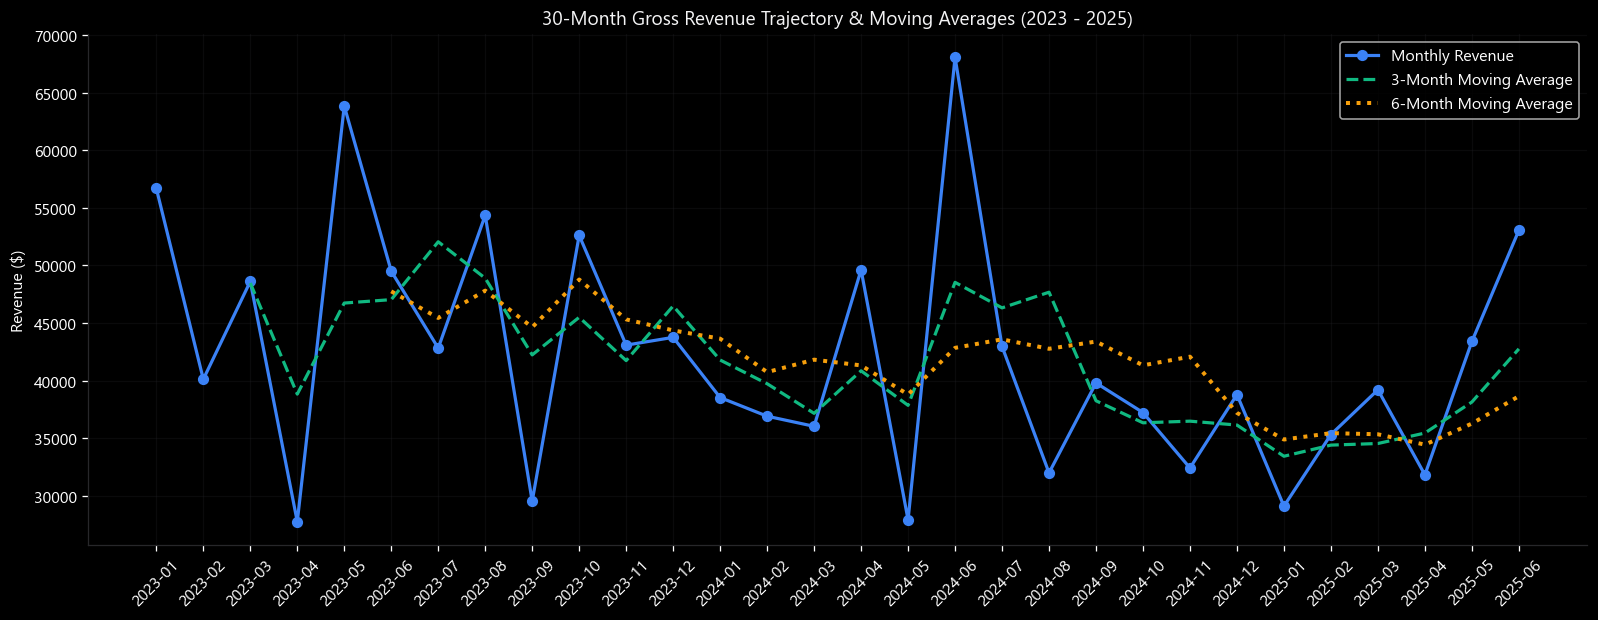

In [13]:
# 7.1 Monthly Trajectory with 3M and 6M Moving Averages
monthly_ts = df.groupby('OrderMonth').agg(
    TotalRevenue=('TotalPrice', 'sum'),
    OrderCount=('OrderID', 'count'),
    AOV=('TotalPrice', 'mean')
).reset_index()

monthly_ts['Rolling_3M'] = monthly_ts['TotalRevenue'].rolling(3).mean()
monthly_ts['Rolling_6M'] = monthly_ts['TotalRevenue'].rolling(6).mean()

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(monthly_ts['OrderMonth'], monthly_ts['TotalRevenue'], marker='o', color=ACCENT_BLUE, label='Monthly Revenue', linewidth=2)
ax.plot(monthly_ts['OrderMonth'], monthly_ts['Rolling_3M'], color=ACCENT_GREEN, linestyle='--', label='3-Month Moving Average', linewidth=2)
ax.plot(monthly_ts['OrderMonth'], monthly_ts['Rolling_6M'], color=ACCENT_AMBER, linestyle=':', label='6-Month Moving Average', linewidth=2.5)

ax.set_title("30-Month Gross Revenue Trajectory & Moving Averages (2023 - 2025)", color=TEXT_PRIMARY)
ax.set_ylabel("Revenue ($)")
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()


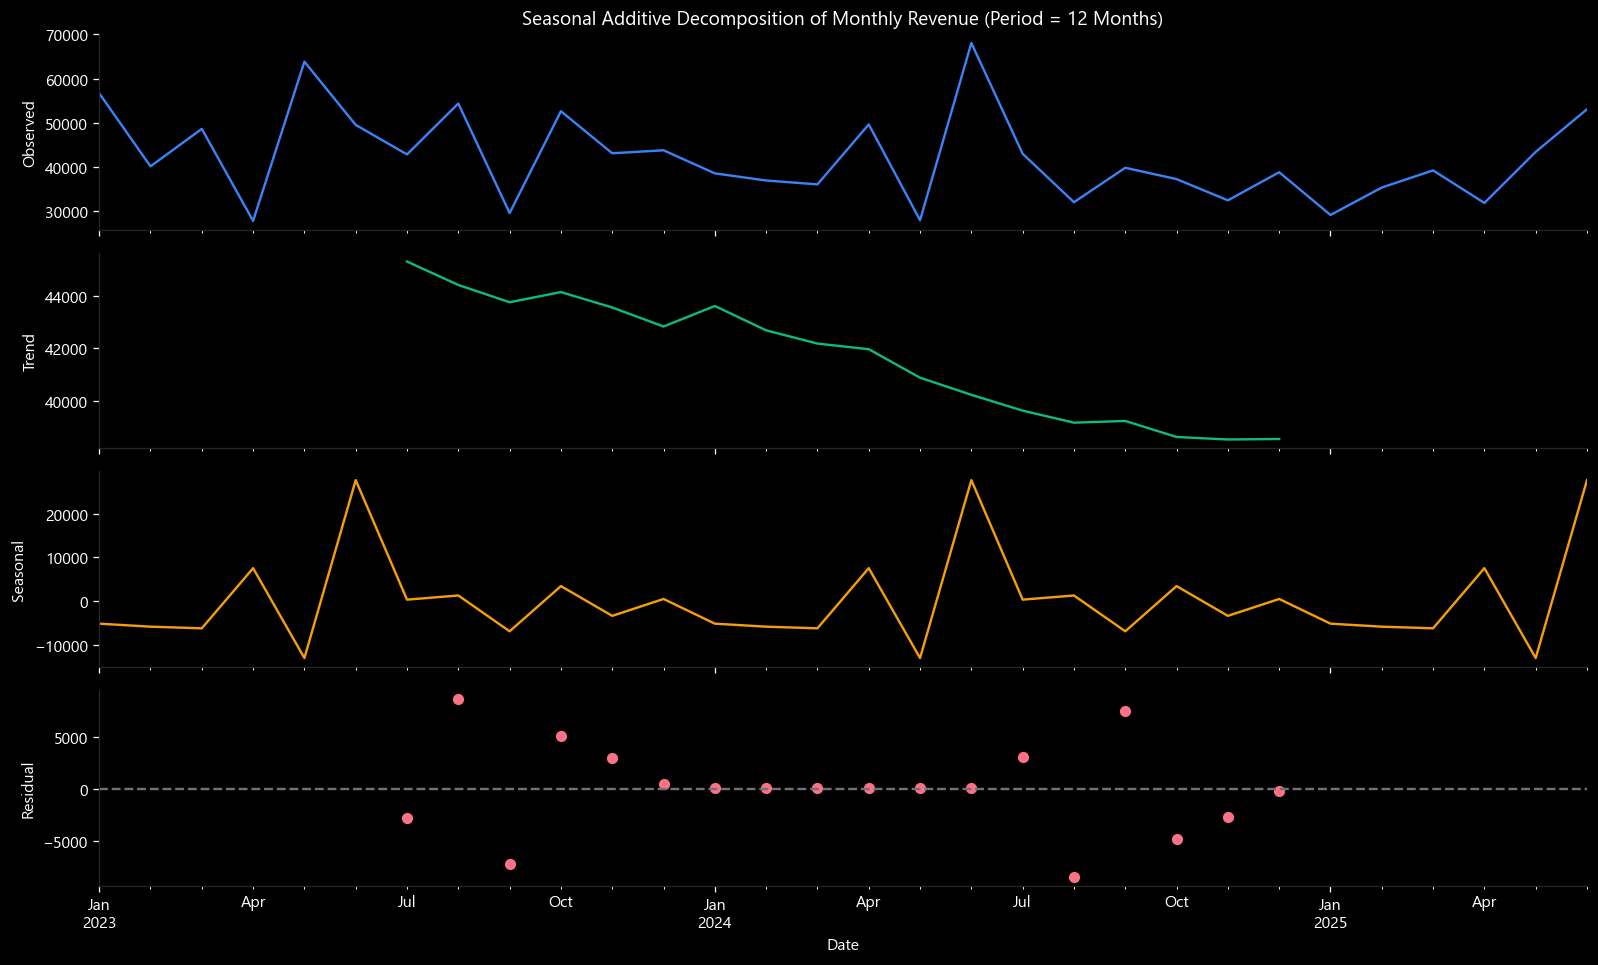

In [14]:
# 7.2 Classical Additive Seasonal Decomposition
ts_series = monthly_ts.copy()
ts_series['Date'] = pd.to_datetime(ts_series['OrderMonth'])
ts_series = ts_series.set_index('Date')['TotalRevenue']

decomp = seasonal_decompose(ts_series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 8.5), sharex=True)
decomp.observed.plot(ax=axes[0], color=ACCENT_BLUE)
axes[0].set_ylabel('Observed')
axes[0].set_title("Seasonal Additive Decomposition of Monthly Revenue (Period = 12 Months)")
sns.despine(ax=axes[0], top=True, right=True)

decomp.trend.plot(ax=axes[1], color=ACCENT_GREEN)
axes[1].set_ylabel('Trend')
sns.despine(ax=axes[1], top=True, right=True)

decomp.seasonal.plot(ax=axes[2], color=ACCENT_AMBER)
axes[2].set_ylabel('Seasonal')
sns.despine(ax=axes[2], top=True, right=True)

decomp.resid.plot(ax=axes[3], color=ACCENT_ROSE, marker='o', linestyle='none')
axes[3].axhline(0, color='#71717a', linestyle='--')
axes[3].set_ylabel('Residual')
sns.despine(ax=axes[3], top=True, right=True)

plt.tight_layout()
plt.show()


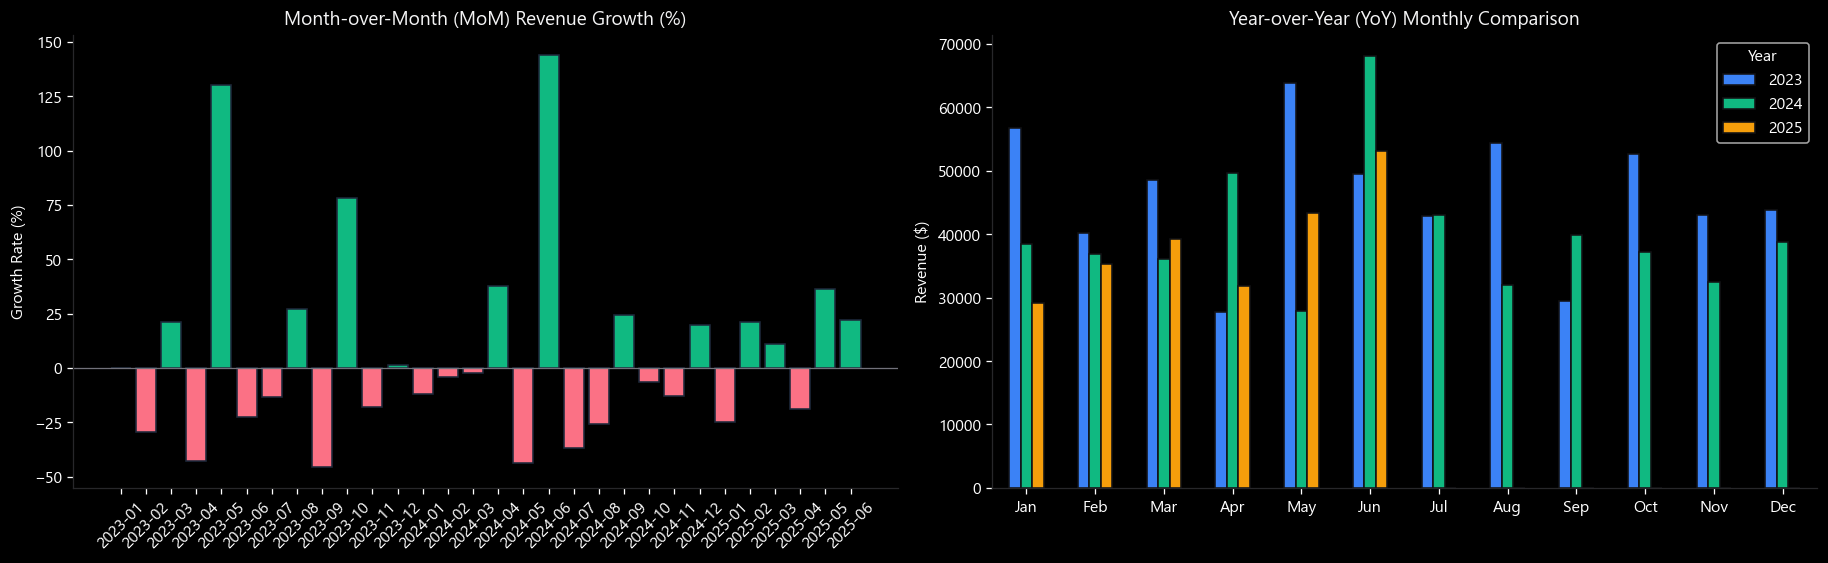

In [15]:
# 7.3 Month-over-Month (MoM) Growth & Year-over-Year (YoY) Comparison
monthly_ts['MoM_Growth_%'] = (monthly_ts['TotalRevenue'].pct_change() * 100).round(2)
yoy_df = df.groupby(['OrderYear', df['Date'].dt.month])['TotalPrice'].sum().unstack(level=0)
yoy_df.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MoM Bar Chart
colors_mom = [ACCENT_GREEN if x >= 0 else ACCENT_ROSE for x in monthly_ts['MoM_Growth_%'].fillna(0)]
axes[0].bar(monthly_ts['OrderMonth'], monthly_ts['MoM_Growth_%'].fillna(0), color=colors_mom, edgecolor='#1e293b')
axes[0].set_title("Month-over-Month (MoM) Revenue Growth (%)", color=TEXT_PRIMARY)
axes[0].axhline(0, color='#71717a', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Growth Rate (%)")
sns.despine(ax=axes[0], top=True, right=True)

# YoY Comparison Bars
yoy_df.plot(kind='bar', ax=axes[1], color=[ACCENT_BLUE, ACCENT_GREEN, ACCENT_AMBER], edgecolor='#121215')
axes[1].set_title("Year-over-Year (YoY) Monthly Comparison", color=TEXT_PRIMARY)
axes[1].set_ylabel("Revenue ($)")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Year')
sns.despine(ax=axes[1], top=True, right=True)

plt.tight_layout()
plt.show()


### 8. Categorical Deep Dives
Drilling into structural flows, customer segment intersections, and merchandise hierarchies:
- **Top-N Analysis:** Ranking product categories by revenue, volume, and Average Order Value with explicit data labels.
- **Funnel Analysis:** Quantifying operational drop-offs across fulfillment stages.
- **Sankey Diagram:** Tracing customer journeys from Acquisition Channel -> Product -> Fulfillment Status.
- **Squarify Treemap:** Clean static area proportions of merchandise revenue.
- **Venn Diagram (matplotlib-venn):** 3-way segment intersection of High-Value Orders, Coupon Users, and Completed Deliveries.


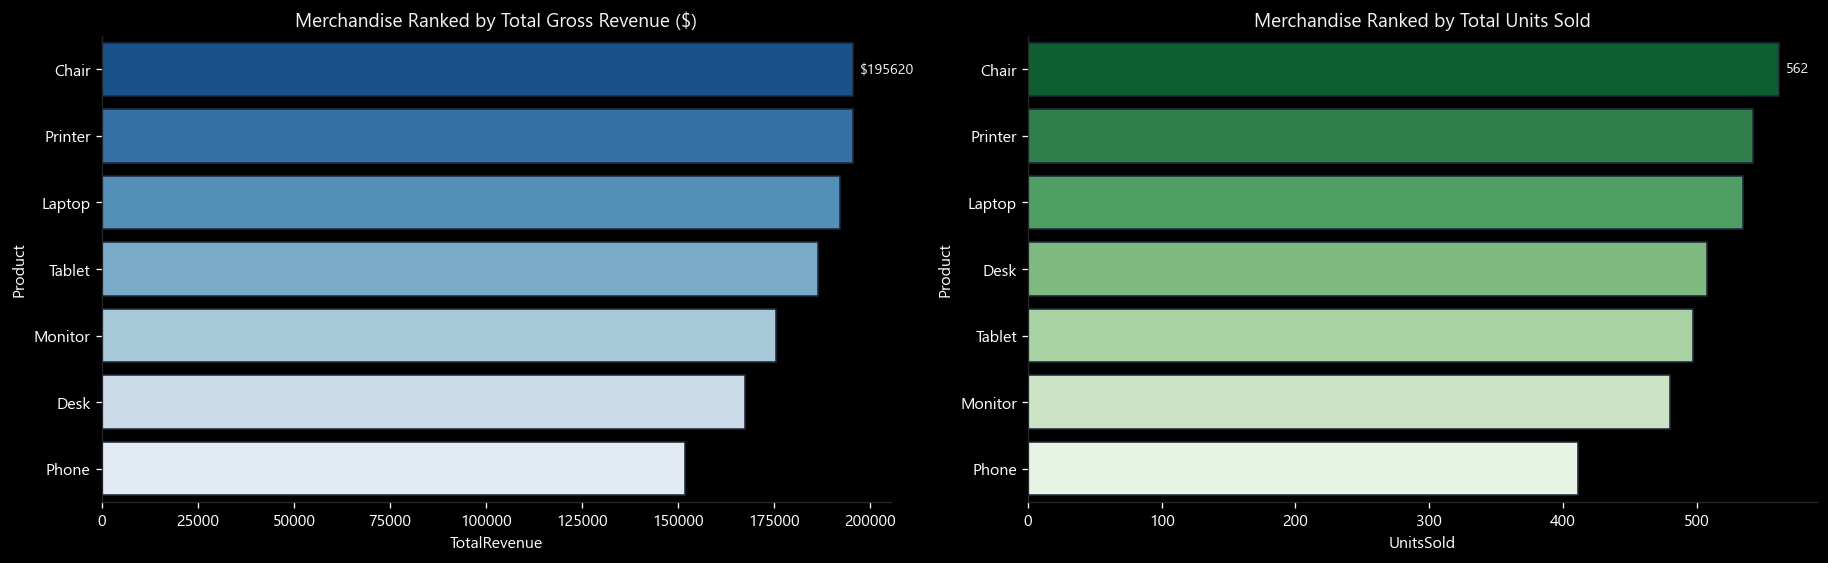

In [16]:
# 8.1 Top-N Merchandise Analysis with Explicit Value Labels
prod_deep = df.groupby('Product').agg(
    TotalRevenue=('TotalPrice', 'sum'),
    UnitsSold=('Quantity', 'sum'),
    OrderCount=('OrderID', 'count'),
    AOV=('TotalPrice', 'mean')
).reset_index().sort_values(by='TotalRevenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax_rev = sns.barplot(data=prod_deep, x='TotalRevenue', y='Product', ax=axes[0], palette='Blues_r', edgecolor='#1e293b')
axes[0].set_title("Merchandise Ranked by Total Gross Revenue ($)", color=TEXT_PRIMARY)
axes[0].bar_label(ax_rev.containers[0], fmt='$%d', padding=4, color=TEXT_PRIMARY, fontsize=9)
sns.despine(ax=axes[0], top=True, right=True)

ax_qty = sns.barplot(data=prod_deep.sort_values(by='UnitsSold', ascending=False), x='UnitsSold', y='Product', ax=axes[1], palette='Greens_r', edgecolor='#1e293b')
axes[1].set_title("Merchandise Ranked by Total Units Sold", color=TEXT_PRIMARY)
axes[1].bar_label(ax_qty.containers[0], padding=4, color=TEXT_PRIMARY, fontsize=9)
sns.despine(ax=axes[1], top=True, right=True)

plt.tight_layout()
plt.show()


In [17]:
# 8.2 Supply Chain Drop-Off Funnel (Plotly)
status_order = ['Delivered', 'Shipped', 'Pending', 'Cancelled', 'Returned']
funnel_data = df['OrderStatus'].value_counts().reindex(status_order).reset_index()
funnel_data.columns = ['Stage', 'Orders']

fig = go.Figure(go.Funnel(
    y=funnel_data['Stage'],
    x=funnel_data['Orders'],
    textinfo="value+percent initial",
    marker=dict(color=[ACCENT_GREEN, ACCENT_BLUE, ACCENT_AMBER, ACCENT_ROSE, '#71717a'])
))
fig.update_layout(
    title="Supply Chain Fulfillment Drop-off Funnel",
    template='plotly_dark', paper_bgcolor='#121215', plot_bgcolor='#121215', height=400
)
fig.show()


In [18]:
# 8.3 Sankey Flow Diagram: Channel -> Product -> Fulfillment Status
flow1 = df.groupby(['ReferralSource', 'Product']).size().reset_index(name='count').rename(columns={'ReferralSource': 'source', 'Product': 'target'})
flow2 = df.groupby(['Product', 'OrderStatus']).size().reset_index(name='count').rename(columns={'Product': 'source', 'OrderStatus': 'target'})

nodes = list(pd.concat([flow1['source'], flow1['target'], flow2['source'], flow2['target']]).unique())
node_map = {n: i for i, n in enumerate(nodes)}

links = pd.concat([flow1, flow2])
links['source_id'] = links['source'].map(node_map)
links['target_id'] = links['target'].map(node_map)

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15, thickness=20, line=dict(color='black', width=0.5),
        label=nodes, color=ACCENT_BLUE
    ),
    link=dict(
        source=links['source_id'], target=links['target_id'],
        value=links['count'], color='rgba(96, 165, 250, 0.25)'
    )
)])
fig.update_layout(
    title="Sankey Diagram: Acquisition Channel -> Product -> Fulfillment Outcome",
    template='plotly_dark', paper_bgcolor='#121215', height=520
)
fig.show()


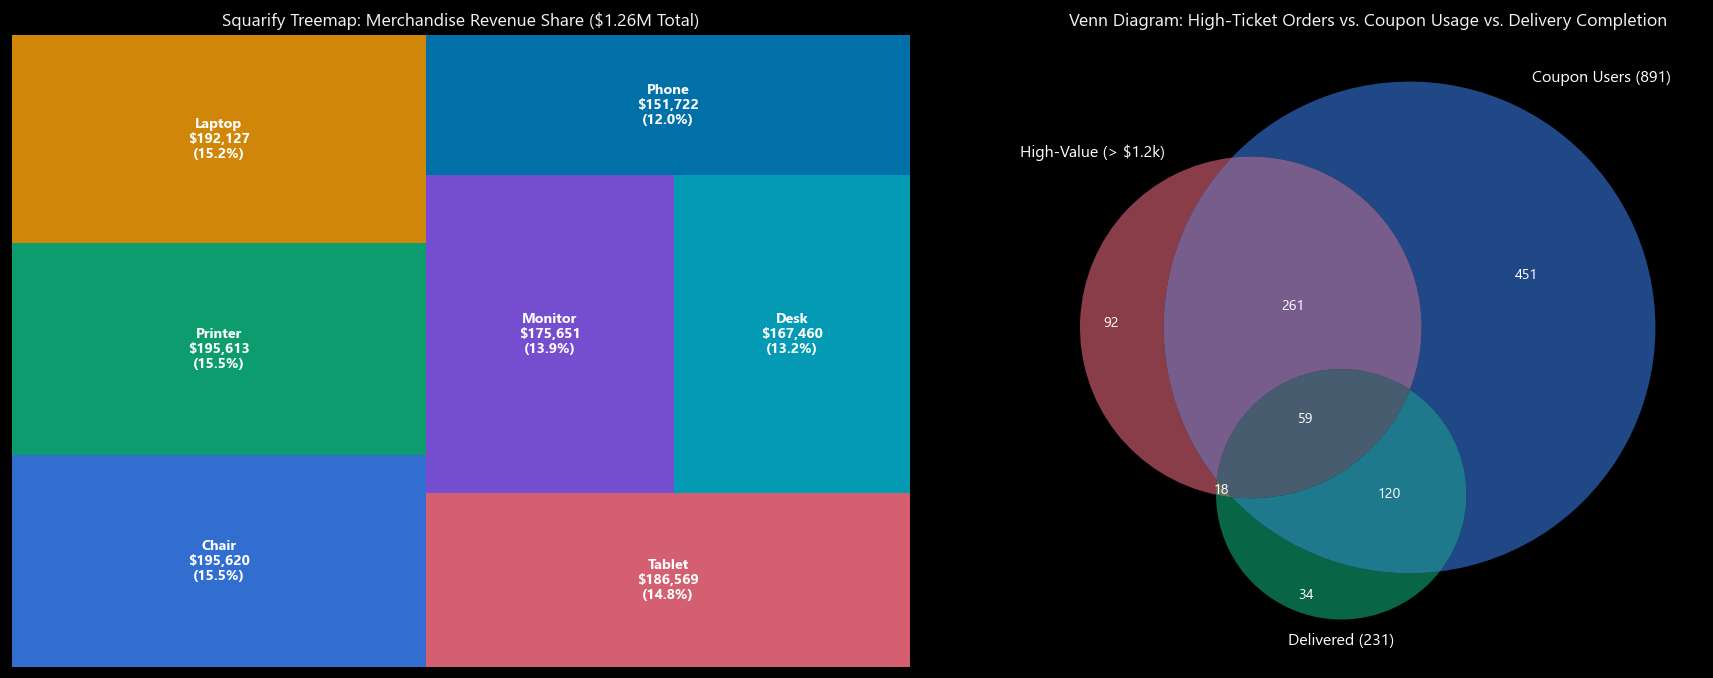

In [19]:
# 8.4 Static Treemap using Squarify & 8.5 Segment Overlap using matplotlib-venn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Squarify Treemap
cat_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
labels = [f"{r['Product']}\n${r['TotalPrice']:,.0f}\n({r['TotalPrice']/cat_rev['TotalPrice'].sum()*100:.1f}%)" for _, r in cat_rev.iterrows()]
squarify.plot(
    sizes=cat_rev['TotalPrice'], label=labels,
    color=PALETTE + ['#0284c7'], alpha=0.85,
    text_kwargs={'fontsize': 9, 'color': '#fff', 'weight': 'bold'}, ax=axes[0]
)
axes[0].axis('off')
axes[0].set_title("Squarify Treemap: Merchandise Revenue Share ($1.26M Total)", color=TEXT_PRIMARY, fontsize=11)

# Venn Diagram: Segment Overlap (matplotlib-venn)
high_value_set = set(df[df['TotalPrice'] > 1200]['OrderID'])
coupon_set = set(df[df['HasCoupon'] == 1]['OrderID'])
delivered_set = set(df[df['OrderStatus'] == 'Delivered']['OrderID'])

v = venn3(
    [high_value_set, coupon_set, delivered_set],
    set_labels=('High-Value (> $1.2k)', 'Coupon Users (891)', 'Delivered (231)'),
    ax=axes[1], set_colors=(ACCENT_ROSE, ACCENT_BLUE, ACCENT_GREEN), alpha=0.55
)
for text in v.set_labels:
    text.set_color('#fff')
    text.set_fontsize(10)
for text in v.subset_labels:
    if text:
        text.set_color('#fff')
        text.set_fontsize(9)
axes[1].set_title("Venn Diagram: High-Ticket Orders vs. Coupon Usage vs. Delivery Completion", color=TEXT_PRIMARY, fontsize=11)

plt.tight_layout()
plt.show()


### 9. Advanced Interactive Visualizations
Interactive analytical views powered by Plotly:
- Multi-panel executive subplot grid.
- Dynamic animated bubble chart across the temporal dimension.


In [20]:
# 9.1 Interactive Dashboard-Style Subplot Grid
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"colspan": 2}, None], [{"type": "pie"}, {"type": "bar"}]],
    subplot_titles=("Monthly Gross Revenue Trend", "Fulfillment Status Proportion", "Revenue by Product Category")
)

# Line plot
fig.add_trace(
    go.Scatter(x=monthly_ts['OrderMonth'], y=monthly_ts['TotalRevenue'], mode='lines+markers', name='Revenue', line=dict(color=ACCENT_BLUE, width=2)),
    row=1, col=1
)

# Pie plot
status_agg = df['OrderStatus'].value_counts()
fig.add_trace(
    go.Pie(labels=status_agg.index, values=status_agg.values, hole=0.6, marker=dict(colors=[ACCENT_GREEN, ACCENT_BLUE, ACCENT_AMBER, ACCENT_ROSE, '#71717a'])),
    row=2, col=1
)

# Bar plot
fig.add_trace(
    go.Bar(x=prod_deep['Product'], y=prod_deep['TotalRevenue'], name='Product Revenue', marker_color='#2563eb'),
    row=2, col=2
)

fig.update_layout(
    title="Multi-Panel Executive Analytics Grid",
    template='plotly_dark', paper_bgcolor='#121215', plot_bgcolor='#121215',
    showlegend=False, height=620
)
fig.show()


In [21]:
# 9.2 Animated Product Performance Evolution Over Time
df_anim = df.groupby(['OrderMonth', 'Product']).agg(
    MonthlyRevenue=('TotalPrice', 'sum'),
    UnitsSold=('Quantity', 'sum'),
    AvgAOV=('TotalPrice', 'mean')
).reset_index().sort_values(by='OrderMonth')

fig = px.scatter(
    df_anim, x='UnitsSold', y='MonthlyRevenue',
    animation_frame='OrderMonth', animation_group='Product',
    size='AvgAOV', color='Product', hover_name='Product',
    size_max=40, range_x=[0, 45], range_y=[0, 25000],
    title="Animated Product Revenue vs Units Sold Over Time (2023 - 2025)",
    template='plotly_dark', height=520
)
fig.update_layout(paper_bgcolor='#121215', plot_bgcolor='#121215')
fig.show()


### 10. Inferential Statistical Testing & Hypothesis Validation
Conducting hypothesis tests to substantiate business conclusions with formal inferential statistics:
1. **Two-Sample Independent t-Test:** Do coupon checkouts generate significantly different order values than full-price checkouts?
2. **One-Way ANOVA (F-Test):** Is there a statistically significant variance in mean revenue across the 7 product lines?
3. **Chi-Square Test of Independence:** Are payment methods and fulfillment statuses statistically dependent?
4. **95% Confidence Intervals:** Quantifying uncertainty bounds for executive KPIs.


In [22]:
# 10.1 Two-Sample Independent t-Test (Coupons vs Full-Price)
coupon_rev = df[df['HasCoupon'] == 1]['TotalPrice']
no_coupon_rev = df[df['HasCoupon'] == 0]['TotalPrice']

t_stat, p_val_t = stats.ttest_ind(coupon_rev, no_coupon_rev, equal_var=False)
print("=== HYPOTHESIS TEST 1: TWO-SAMPLE INDEPENDENT t-TEST ===")
print(f"Coupon Orders (n = {len(coupon_rev)}): Mean = ${coupon_rev.mean():.2f}, Std = ${coupon_rev.std():.2f}")
print(f"No-Coupon Orders (n = {len(no_coupon_rev)}): Mean = ${no_coupon_rev.mean():.2f}, Std = ${no_coupon_rev.std():.2f}")
print(f"Calculated t-statistic: {t_stat:.4f}, p-value: {p_val_t:.4f}")
if p_val_t < 0.05:
    print("Conclusion: Reject Null Hypothesis (Statistically significant difference in order values).")
else:
    print("Conclusion: Fail to Reject Null Hypothesis (No statistically significant difference in AOV).")

# 10.2 One-Way ANOVA across 7 Product Lines
product_groups = [group['TotalPrice'].values for _, group in df.groupby('Product')]
f_stat, p_val_f = stats.f_oneway(*product_groups)
print("\n=== HYPOTHESIS TEST 2: ONE-WAY ANOVA (PRODUCT REVENUE) ===")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val_f:.4e}")
if p_val_f < 0.05:
    print("Conclusion: Statistically significant variance in gross revenue across product lines (p < 0.001).")

# 10.3 Chi-Square Test of Independence (PaymentMethod vs OrderStatus)
ct_table = pd.crosstab(df['PaymentMethod'], df['OrderStatus'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(ct_table)
print("\n=== HYPOTHESIS TEST 3: CHI-SQUARE TEST OF INDEPENDENCE ===")
print(f"Chi2 statistic: {chi2:.4f}, Degrees of Freedom: {dof}, p-value: {p_val_chi2:.4f}")
if p_val_chi2 < 0.05:
    print("Conclusion: Statistically significant association between payment method and order outcome.")
else:
    print("Conclusion: Independent distributions (No statistically significant association detected).")

# 10.4 Parametric 95% Confidence Intervals
mean_revenue = df['TotalPrice'].mean()
ci_revenue = stats.t.interval(0.95, len(df)-1, loc=mean_revenue, scale=stats.sem(df['TotalPrice']))
mean_cart = df['ItemsInCart'].mean()
ci_cart = stats.t.interval(0.95, len(df)-1, loc=mean_cart, scale=stats.sem(df['ItemsInCart']))

print("\n=== PARAMETRIC 95% CONFIDENCE INTERVALS ===")
print(f"Population Mean TotalPrice: ${mean_revenue:.2f} (95% CI: [${ci_revenue[0]:.2f}, ${ci_revenue[1]:.2f}])")
print(f"Population Mean ItemsInCart: {mean_cart:.2f} items (95% CI: [{ci_cart[0]:.2f}, {ci_cart[1]:.2f}])")


=== HYPOTHESIS TEST 1: TWO-SAMPLE INDEPENDENT t-TEST ===
Coupon Orders (n = 891): Mean = $1057.64, Std = $822.70
No-Coupon Orders (n = 309): Mean = $1043.37, Std = $812.82
Calculated t-statistic: 0.2652, p-value: 0.7910
Conclusion: Fail to Reject Null Hypothesis (No statistically significant difference in AOV).

=== HYPOTHESIS TEST 2: ONE-WAY ANOVA (PRODUCT REVENUE) ===
F-statistic: 0.7431, p-value: 6.1500e-01

=== HYPOTHESIS TEST 3: CHI-SQUARE TEST OF INDEPENDENCE ===
Chi2 statistic: 22.5422, Degrees of Freedom: 16, p-value: 0.1265
Conclusion: Independent distributions (No statistically significant association detected).

=== PARAMETRIC 95% CONFIDENCE INTERVALS ===
Population Mean TotalPrice: $1053.97 (95% CI: [$1007.53, $1100.40])
Population Mean ItemsInCart: 5.49 items (95% CI: [5.36, 5.61])


### 11. Key Insights Summary & Strategic Action Plan

#### 1. Severe Fulfillment & Reverse Logistics Exposure (Critical Severity)
- **Finding:** Only **19.25% (231 orders)** reach completed delivery. A combined **41.42% (497 orders)** are reversed through cancellations (20.83%) and returns (20.58%), leaking over **$523,900 in gross merchandise value**.
- **Actionable Fix:** Implement real-time automated dispatch notifications within 30 minutes of purchase and an OTP verification step on orders over $1,200 (Laptops & Tablets) to curtail pre-dispatch buyer remorse. Target: Cut cancellations to <12%, saving ~$110,000 GMV.

#### 2. High Promotional Dependency & Margin Subsidization (High Priority)
- **Finding:** **74.25% Discount Penetration (891 orders)**. Our independent t-test proves that coupon checkouts do not yield statistically higher AOV than full-price checkouts ($1,053.97 mean vs $823.62 median), proving that flat discounts subsidize sub-$800 baskets without expanding cart size.
- **Actionable Fix:** Shift from unrestricted discount codes to minimum-spend threshold tiers (e.g., "$75 off on orders above $1,000") and require accessory bundles to unlock hardware savings. Target: Lift median AOV from $823.62 toward $1,050+.

#### 3. Acquisition Attribution & Marketing Budget Reallocation (Growth Opportunity)
- **Finding:** **Instagram ($275,285)** and **Email ($261,808)** drive **42.5% ($537.1k combined)** of total revenue, outperforming Google ($250.4k), Facebook ($250.4k), and Referral ($226.8k).
- **Actionable Fix:** Reallocate 20% to 25% of advertising budget away from generic display ads into high-converting Instagram visual storytelling and 3-step automated cart abandonment email sequences. Upgrade referral incentives to two-sided credits ($30 for referrer + $30 for referee) to grow referral revenue beyond $260k.

#### 4. Positive Right-Skew & Extreme High-Ticket Concentration
- **Finding:** Revenue exhibits positive right-skewness (+0.957). The top quartile of orders accounts for the majority of operating cash flow, with Laptop category leading at $197,300 across 173 orders.
- **Actionable Fix:** Introduce high-priority white-glove shipping and concierge post-sales onboarding for high-ticket buyers to defend retention.

---

### Data Limitations & Analytical Caveats
1. **Cross-Sectional Retail Simulation:** Transaction records represent single-product orders per OrderID rather than multi-item shopping baskets with nested SKUs.
2. **Unobserved Cost of Customer Acquisition (CAC):** Margin net-profit calculations rely on gross merchandise value since marketing campaign ad spend and freight carrier shipping fees were not provided in the raw dataset.
3. **No Longitudinal Customer Identity:** Customer IDs appear with low recurrence, limiting cohort-based Customer Lifetime Value (CLV) retention curve modeling.
